# CreditMetrics Demo
This notebook demonstrates how to use the project after refactoring. The implementation lives in `src/`; this notebook simply orchestrates the workflow.

In [1]:
from src.simulation import (
    generate_correlated_returns,
    map_returns_to_ratings,
    generate_recovery_rates,
)

from src.portfolio import (
    calculate_loan_forward_values,
    calculate_portfolio_values,
)

from src.risk_metrics import (
    calculate_losses,
    calculate_var_and_es
)

from src.visualisation import plot_loss_distribution


## 1. Define model parameters

In [2]:
import numpy as np

In [18]:
NUM_SCENARIOS = 50000
CONFIDENCE_LEVELS = [0.95, 0.99]
np.random.seed(42)
 
# Ratings (ordered from best to worst)
RATINGS = ['Aa', 'Aa', 'A', 'Baa', 'Ba', 'B', 'Caa-C', 'Default']
RATING_INDEX = {rating: i for i, rating in enumerate(RATINGS)}

bond_names = ['Boyd Gaming Corp', 'Brinker International Inc', 'American Airlines Group Inc']

# Current exposures (in dollars)
exposures = {
    'Boyd Gaming Corp': 4_000_000,
    'Brinker International Inc': 5_000_000,
    'American Airlines Group Inc': 6_000_000
}

# Current forward values at t=0 (should be close to exposures) (Calculation can be found in data/valuation.csv)
current_values = {
    'Boyd Gaming Corp': 3_980_869,
    'Brinker International Inc': 5_125_176,
    'American Airlines Group Inc': 6_116_918
    }

initial_portfolio_value = sum(current_values.values())

# Forward values at 1-year horizon for each rating. (Calculation can be found in data/valuation.csv)
forward_values = {
    'Boyd Gaming Corp': {
        'Aaa': 4_105_450,
        'Aa': 4_077_394,
        'A': 4_065_235,
        'Baa': 4_042_173,
        'Ba': 3_978_112,
        'B': 3_890_678,
        'Caa-C': 3_688_288,
        'Default': 0  # Will be overridden by recovery × exposure
            },
    'Brinker International Inc': {
        'Aaa': 5_319_568,
        'Aa': 5_266_557,
        'A': 5_245_895,
        'Baa': 5_201_549,
        'Ba': 5_080_615,
        'B': 4_932_823,
        'Caa-C': 4_569_623,
        'Default': 0
    },
    'American Airlines Group Inc': {
        'Aaa': 6_698_778,
        'Aa': 6_612_932,
        'A': 6_582_203,
        'Baa': 6_509_991,
        'Ba': 6_313_624,
        'B': 6_098_192,
        'Caa-C': 5_534_339,
        'Default': 0
    }
}

# Cholesky matrix (3x3 lower triangular for 3 bonds) (Calculation can be found in data/correlation.csv)
cholesky_matrix = np.array([
    [1.0000, 0.0000, 0.0000],
    [0.5219, 0.8530, 0.0000],
    [0.4665, 0.2129, 0.8585]
])

# Rating thresholds.
# Structure: thresholds[bond][rating] = threshold value (Calculation can be found in data/thresholds.csv)
rating_thresholds = {
    "Boyd Gaming Corp": {
    "thresholds": np.array([-2.6336,-2.2361,-1.5621,2.6336]),
    "states": ["Default", "Caa-C", "B", "Ba", "Baa"]
    },
    "Brinker International Inc": {
    "thresholds": np.array([-2.6336,-2.2361,-1.5621,2.6336]),
    "states": ["Default", "Caa-C", "B", "Ba", "Baa"]
    },
    "American Airlines Group Inc": {
    "thresholds": np.array([-2.1082,0.8566,2.3759]),
    "states": ["Caa-C", "B", "Ba", "Baa"]
    }
}

# Recovery rate distribution parameters (Beta distribution). (Calculation can be found in data/valuation.csv)
# Same alpha and beta for all bonds (Senior Unsecured)
alpha = 8.3653      # Beta alpha parameter
beta_param = 13.7068 # Beta beta parameter

print(f"\nPortfolio Configuration:")
print(f"  Bonds: {', '.join(bond_names)}")
print(f"  Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"  Number of Scenarios: {NUM_SCENARIOS:,}")
print(f"  Recovery Distribution: Beta(α={alpha}, β={beta_param})")
print(f"  Correlation Structure: Cholesky-induced")


Portfolio Configuration:
  Bonds: Boyd Gaming Corp, Brinker International Inc, American Airlines Group Inc
  Initial Portfolio Value: $15,222,963.00
  Number of Scenarios: 50,000
  Recovery Distribution: Beta(α=8.3653, β=13.7068)
  Correlation Structure: Cholesky-induced


## 2. Generate simulated scenarios

In [19]:
print(f"Generating {NUM_SCENARIOS:,} correlated asset return scenarios...")
correlated_returns, uncorrelated_returns = generate_correlated_returns(
    NUM_SCENARIOS, cholesky_matrix, num_bonds=3
)

print(f"\nMapping returns to rating scenarios using thresholds...")
rating_scenarios = map_returns_to_ratings(
    correlated_returns, rating_thresholds
)

print(f"  Uncorrelated returns shape: {uncorrelated_returns.shape}")
print(f"  Correlated returns shape: {correlated_returns.shape}")
print(f"  Correlation matrix (from data):\n{np.corrcoef(correlated_returns.T)}")

# Summary of rating distributions
for bond_name in bond_names:
    ratings = rating_scenarios[bond_name]
    unique, counts = np.unique(ratings, return_counts=True)
    print(f"\n  {bond_name}:")
    for rating_label, count in zip(unique, counts):
        pct = (count / NUM_SCENARIOS) * 100
        print(f"    {rating_label:8s}: {count:>6,} scenarios ({pct:>5.2f}%)")

print(f"\nGenerating uncorrelated recovery rates using Beta distribution...")
recovery_rates, uniform_random = generate_recovery_rates(
    NUM_SCENARIOS, alpha, beta_param, num_bonds=3
)

print(f"  Uniform random values shape: {uniform_random.shape}")
print(f"  Recovery rates shape: {recovery_rates.shape}")
print(f"  Recovery statistics:")
print(f"  Mean recovery: {np.mean(recovery_rates):.4f}")
print(f"  Std recovery:  {np.std(recovery_rates):.4f}")
print(f"  Min recovery:  {np.min(recovery_rates):.4f}")
print(f"  Max recovery:  {np.max(recovery_rates):.4f}")

Generating 50,000 correlated asset return scenarios...

Mapping returns to rating scenarios using thresholds...
  Uncorrelated returns shape: (50000, 3)
  Correlated returns shape: (50000, 3)
  Correlation matrix (from data):
[[1.         0.525958   0.46465949]
 [0.525958   1.         0.4288979 ]
 [0.46465949 0.4288979  1.        ]]

  Boyd Gaming Corp:
    B       :  2,372 scenarios ( 4.74%)
    Ba      : 46,780 scenarios (93.56%)
    Baa     :    212 scenarios ( 0.42%)
    Caa-C   :    431 scenarios ( 0.86%)
    Default :    205 scenarios ( 0.41%)

  Brinker International Inc:
    B       :  2,325 scenarios ( 4.65%)
    Ba      : 46,771 scenarios (93.54%)
    Baa     :    241 scenarios ( 0.48%)
    Caa-C   :    441 scenarios ( 0.88%)
    Default :    222 scenarios ( 0.44%)

  American Airlines Group Inc:
    B       : 39,210 scenarios (78.42%)
    Ba      :  9,478 scenarios (18.96%)
    Baa     :    443 scenarios ( 0.89%)
    Caa-C   :    869 scenarios ( 1.74%)

Generating uncorrelat

## 3. Value the portfolio

In [20]:
print(f"\nCalculating implied forward loan values...")
loan_forward_values = calculate_loan_forward_values(
    rating_scenarios, recovery_rates, forward_values, exposures
)

for bond_name in bond_names:
    values = loan_forward_values[bond_name]
    print(f"\n  {bond_name}:")
    print(f"    Mean forward value: ${np.mean(values):>15,.2f}")
    print(f"    Std forward value:  ${np.std(values):>15,.2f}")
    print(f"    Min forward value:  ${np.min(values):>15,.2f}")
    print(f"    Max forward value:  ${np.max(values):>15,.2f}")

print(f"\nAggregating to portfolio values...")
portfolio_values = calculate_portfolio_values(loan_forward_values)
    
print(f"  Portfolio values shape: {portfolio_values.shape}")
print(f"  Portfolio value statistics:")
print(f"  Mean portfolio value: ${np.mean(portfolio_values):>15,.2f}")
print(f"  Std portfolio value:  ${np.std(portfolio_values):>15,.2f}")
print(f"  Min portfolio value:  ${np.min(portfolio_values):>15,.2f}")
print(f"  Max portfolio value:  ${np.max(portfolio_values):>15,.2f}")



Calculating implied forward loan values...

  Boyd Gaming Corp:
    Mean forward value: $   3,961,476.71
    Std forward value:  $     164,768.64
    Min forward value:  $     417,107.08
    Max forward value:  $   4,042,173.00

  Brinker International Inc:
    Mean forward value: $   5,055,906.61
    Std forward value:  $     217,901.03
    Min forward value:  $     848,704.24
    Max forward value:  $   5,201,549.00

  American Airlines Group Inc:
    Mean forward value: $   6,132,878.06
    Std forward value:  $     120,924.06
    Min forward value:  $   5,534,339.00
    Max forward value:  $   6,509,991.00

Aggregating to portfolio values...
  Portfolio values shape: (50000,)
  Portfolio value statistics:
  Mean portfolio value: $  15,150,261.39
  Std portfolio value:  $     327,113.08
  Min portfolio value:  $   8,437,829.07
  Max portfolio value:  $  15,753,713.00


## 4. Calculate portfolio risk

In [23]:
print(f"\nCalculating portfolio losses...")
losses = calculate_losses(portfolio_values, initial_portfolio_value)
    
print(f"  Loss statistics:")
print(f"    Mean loss:    ${np.mean(losses):>15,.2f}")
print(f"    Median loss:  ${np.median(losses):>15,.2f}")
print(f"    Std loss:     ${np.std(losses):>15,.2f}")
print(f"    Min loss:     ${np.min(losses):>15,.2f}")
print(f"    Max loss:     ${np.max(losses):>15,.2f}")

print(f"\nCalculating Absolute VaR and Expected Shortfall...")
results = calculate_var_and_es(losses, CONFIDENCE_LEVELS)

for conf in sorted(CONFIDENCE_LEVELS):
    conf_pct = int(conf * 100)
    var = results[conf]['VaR']
    es = results[conf]['ES']
        
    print(f"\nConfidence Level: {conf_pct}%")
    print(f"  Absolute VaR:              ${var:>15,.2f}")
    print(f"  Absolute Expected Shortfall: ${es:>15,.2f}")
    print(f"  Tail Observations:         {results[conf]['num_tail']:>15,} ({results[conf]['pct_tail']:.2f}%)")



Calculating portfolio losses...
  Loss statistics:
    Mean loss:    $      72,701.61
    Median loss:  $      66,044.00
    Std loss:     $     327,113.08
    Min loss:     $    -530,750.00
    Max loss:     $   6,785,133.93

Calculating Absolute VaR and Expected Shortfall...

Confidence Level: 95%
  Absolute VaR:              $     213,836.00
  Absolute Expected Shortfall: $     694,018.19
  Tail Observations:                   3,879 (7.76%)

Confidence Level: 99%
  Absolute VaR:              $     866,860.00
  Absolute Expected Shortfall: $   2,755,088.59
  Tail Observations:                     513 (1.03%)


## 5. Visualise results

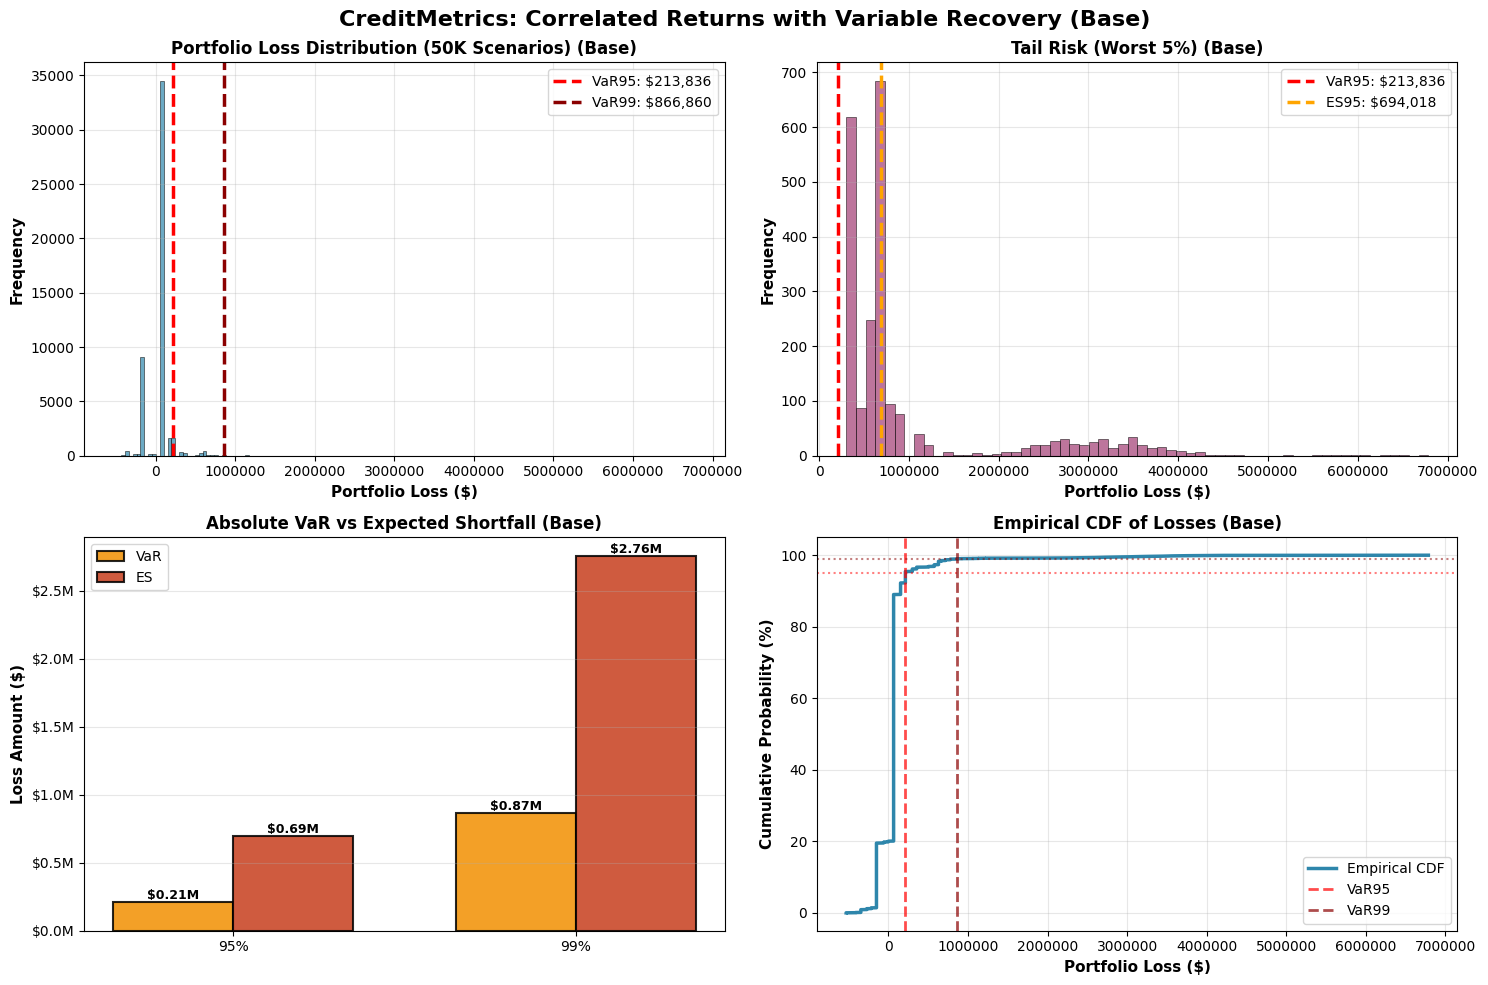

In [22]:
plot_loss_distribution(losses, results)